<a href="https://colab.research.google.com/github/EmePin/Analisis-de-datos/blob/main/Analysis_SleepHealth%26Lifestyle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calidad de sueño y estilo de vida

En este conjunto de datos sacado de [Kaggle](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset) cuenta con datos de la calidad de sueño de distintas personas, las columnas que se encuentran son las siguientes:

- Person ID: Un identificador para cada individuo
- Gener: El género de la persona (Hombre / Mujer)
- Age: La edad de las personas en años
- Occupation: - La ocupación o profesión de la persona
- Sleep Duration (hours) - El número de horas que la persona duerme por día
- Quality Sleep (scale: 1-10) - Una calificación subjetiva de la calidad del sueño
- Physical Activity Level (minutes/day) - El número de minutos que la persona hace actividad física diariamente
- Stress Level (scale: 1-10) - Una calificacoón subjetiva del nivel de estres experimentado por la persona
- BMI Category - La categoría de Índice de Masa Corporal
- Blood Pressure (systolic/diastolic) - La presión arterial de la persona, indicado como presión sistólica sobre presión diastólica
- Heart Rate (bpm) - La frecuencia cardíaca en reposo en latidos por minuto
- Dialy Steps - El número de pasos que la persona hace al día
- Sleep Disorder - La presencia o ausensica de transtornos del sueño en la persona.

## Preguntas que buscamos responder con este conjunto

Las preguntas que buscaremos responder con este conjunto de datos son las siguientes:

- ¿Quiénes tienen peor calidad del sueño, hombres o mujeres?

- ¿Existe una relación entre la calidad del sueño de las personas y su profesión?

- ¿La actividad física afecta al sueño?

- ¿Qué profesión presenta la peor calidad de sueño?

- ¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?

- ¿En qué rango de edades se encuentran la mayor cantidad de trastornos del sueño?

- La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?

Con estas preguntas comenzaremos a hacer nuestro análisis buscando extraer la mayor cantidad de información que se pueda del conjunto, es importante señalar que en este proyecto solamente haremos análisis de datos utilizando la librería **Pandas**.



In [176]:
try:
    import kagglehub
    import pandas as pd
except ImportError:
    !pip install kagglehub
    !pip install pandas

path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
print("Path to dataset files:", path)
# Assuming the dataset is a CSV file
df = pd.read_csv(path + "/Sleep_health_and_lifestyle_dataset.csv",index_col="Person ID")


df.head() # Print the first few rows to verify



Path to dataset files: /kaggle/input/sleep-health-and-lifestyle-dataset


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
Person ID,,,,,,,,,,,,
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [175]:
df.tail()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age_group
Person ID,,,,,,,,,,,,,
370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult


In [148]:
# Información general del conjunto
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 1 to 374
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 38.0+ KB


In [149]:
# Descripción general de las variables numericas del conjunto
df.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


##Análisis de edades

In [150]:
#¿Cuántos Hombres y mujeres hay en los datos?
df['Gender'].value_counts()

,count
Gender,
Male,189
Female,185


In [151]:
# Promedio de la edad
df['Age'].mean()

np.float64(42.18449197860963)

In [152]:
# Desviación estándar del conjunto
df['Age'].std()

8.67313346554724

In [153]:
# Creamos una columna nueva para ordenar por adulto y adulto viejo
df.loc[df['Age']<=40, 'Age_group'] = 'Adult'
df.loc[df['Age']>=41, 'Age_group'] = 'Older Adult'

In [154]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age_group
Person ID,,,,,,,,,,,,,
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,Adult
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Adult
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Adult
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Adult
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Adult


In [155]:
# Cantidad de adultos y adultos viejos del conjunto
df['Age_group'].value_counts()

,count
Age_group,
Older Adult,209
Adult,165


In [156]:
# Promedio y desviación estándar de las edades divididas entre hombres y mujeres
df.groupby('Gender')['Age'].agg(['mean', 'std'])

,mean,std
Gender,,
Female,47.405405,8.093407
Male,37.074074,5.662006


##Análisis de las ocupaciones

In [157]:
# Cantidad de hombres y mujeres
df.groupby(['Occupation'])['Gender'].value_counts()

Occupation            Gender
Accountant            Female    36
                      Male       1
Doctor                Male      69
                      Female     2
Engineer              Female    32
                      Male      31
Lawyer                Male      45
                      Female     2
Manager               Female     1
Nurse                 Female    73
Sales Representative  Male       2
Salesperson           Male      32
Scientist             Female     4
Software Engineer     Male       4
Teacher               Female    35
                      Male       5
Name: count, dtype: int64

In [158]:
# Duración del sueño entre hombres y mujeres
df.groupby(['Gender'])['Sleep Duration'].mean()

,Sleep Duration
Gender,
Female,7.229730
Male,7.036508


In [159]:
# promedio de la calidad del sueño entre hombres y mujeres
df.groupby('Gender')['Quality of Sleep'].mean()

,Quality of Sleep
Gender,
Female,7.664865
Male,6.968254


In [160]:
# Promedio de la calidad y duración del sueño
occ_qua=df.groupby('Occupation')[['Quality of Sleep', 'Sleep Duration']].mean()
occ_qua.sort_values(by='Quality of Sleep')

,Quality of Sleep,Sleep Duration
Occupation,,
Sales Representative,4.000000,5.900000
Scientist,5.000000,6.000000
Salesperson,6.000000,6.403125
Software Engineer,6.500000,6.750000
Doctor,6.647887,6.970423
Teacher,6.975000,6.690000
Manager,7.000000,6.900000
Nurse,7.369863,7.063014
Accountant,7.891892,7.113514


In [161]:
print("# Promedio de la calidad y duración del sueño")
gender_occ_qua = df.groupby(['Occupation', 'Gender'])[['Quality of Sleep', 'Sleep Duration']].mean()
gender_occ_qua.sort_values(by=['Occupation', ('Quality of Sleep')])

# Promedio de la calidad y duración del sueño


Quality of Sleep  Sleep Duration
Occupation           Gender                                  
Accountant           Female          7.888889        7.111111
                     Male            8.000000        7.200000
Doctor               Male            6.579710        6.934783
                     Female          9.000000        8.200000
Engineer             Male            7.806452        7.535484
                     Female          9.000000        8.425000
Lawyer               Female          7.000000        7.150000
                     Male            7.933333        7.422222
Manager              Female          7.000000        6.900000
Nurse                Female          7.369863        7.063014
Sales Representative Male            4.000000        5.900000
Salesperson          Male            6.000000        6.403125
Scientist            Female          5.000000        6.000000
Software Engineer    Male            6.500000        6.750000
Teacher              Male            6.000000        6.580000
                     Female          7.114286        6.705714

In [162]:
print("# Promedio de la calidad y duración del sueño")
gender_occ_qua = df.groupby(['Occupation', 'Gender'])[['Quality of Sleep', 'Sleep Duration']].mean()
pivot_occ_qua = gender_occ_qua.pivot_table(index='Occupation', columns='Gender', values=['Quality of Sleep', 'Sleep Duration'])
pivot_occ_qua.sort_values(by=('Quality of Sleep', 'Female'))

# Promedio de la calidad y duración del sueño


Quality of Sleep           Sleep Duration          
Gender                         Female      Male         Female      Male
Occupation                                                              
Scientist                    5.000000       NaN       6.000000       NaN
Lawyer                       7.000000  7.933333       7.150000  7.422222
Manager                      7.000000       NaN       6.900000       NaN
Teacher                      7.114286  6.000000       6.705714  6.580000
Nurse                        7.369863       NaN       7.063014       NaN
Accountant                   7.888889  8.000000       7.111111  7.200000
Engineer                     9.000000  7.806452       8.425000  7.535484
Doctor                       9.000000  6.579710       8.200000  6.934783
Sales Representative              NaN  4.000000            NaN  5.900000
Salesperson                       NaN  6.000000            NaN  6.403125
Software Engineer                 NaN  6.500000            NaN  6.750000

In [163]:
occ_bmi = df.groupby('Occupation')['BMI Category'].value_counts()

occ_bmi.sort_values()

Occupation            BMI Category 
Lawyer                Normal Weight     1
Manager               Overweight        1
Software Engineer     Obese             1
                      Overweight        1
Teacher               Obese             1
Lawyer                Obese             2
Doctor                Normal Weight     2
Lawyer                Overweight        2
Sales Representative  Obese             2
Software Engineer     Normal Weight     2
Engineer              Overweight        3
Scientist             Overweight        4
Engineer              Normal Weight     4
Doctor                Obese             4
Accountant            Normal Weight     5
                      Overweight        6
Teacher               Normal            6
Nurse                 Normal Weight     7
Accountant            Normal           26
Salesperson           Overweight       32
Teacher               Overweight       33
Lawyer                Normal           42
Engineer              Normal           56
Doctor                Normal           65
Nurse                 Overweight       66
Name: count, dtype: int64

In [164]:
occ_steps = df.groupby(['Occupation'])[['Daily Steps', 'Physical Activity Level', 'Sleep Duration', 'Quality of Sleep']].mean()
occ_steps.sort_values(by='Daily Steps')

,Daily Steps,Physical Activity Level,Sleep Duration,Quality of Sleep
Occupation,,,,
Sales Representative,3000.000000,30.000000,5.900000,4.000000
Scientist,5350.000000,41.000000,6.000000,5.000000
Manager,5500.000000,55.000000,6.900000,7.000000
Software Engineer,5800.000000,48.000000,6.750000,6.500000
Teacher,5957.500000,45.625000,6.690000,6.975000
Engineer,5980.952381,51.857143,7.987302,8.412698
Salesperson,6000.000000,45.000000,6.403125,6.000000
Doctor,6808.450704,55.352113,6.970423,6.647887
Accountant,6881.081081,58.108108,7.113514,7.891892


<ipython-input-173-e5d8e639c52b>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Quality of Sleep', data=df, errorbar='sd', palette=vibrant_palette)


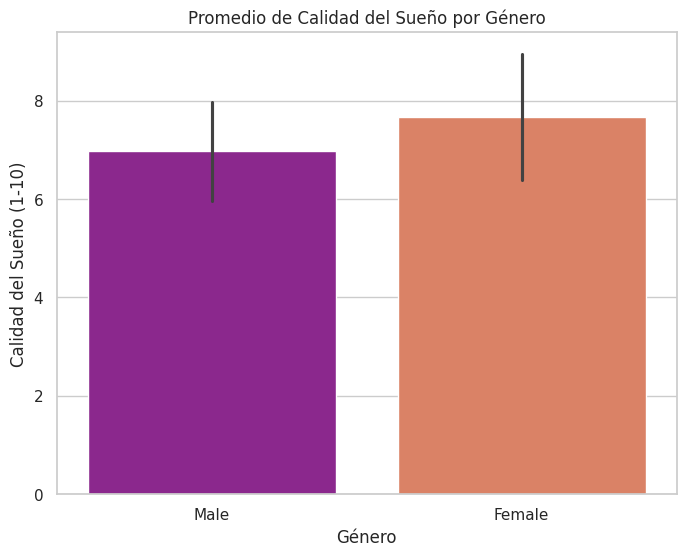

<ipython-input-173-e5d8e639c52b>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BMI Category', y='Sleep Duration', data=df, palette=orange_purple_palette)


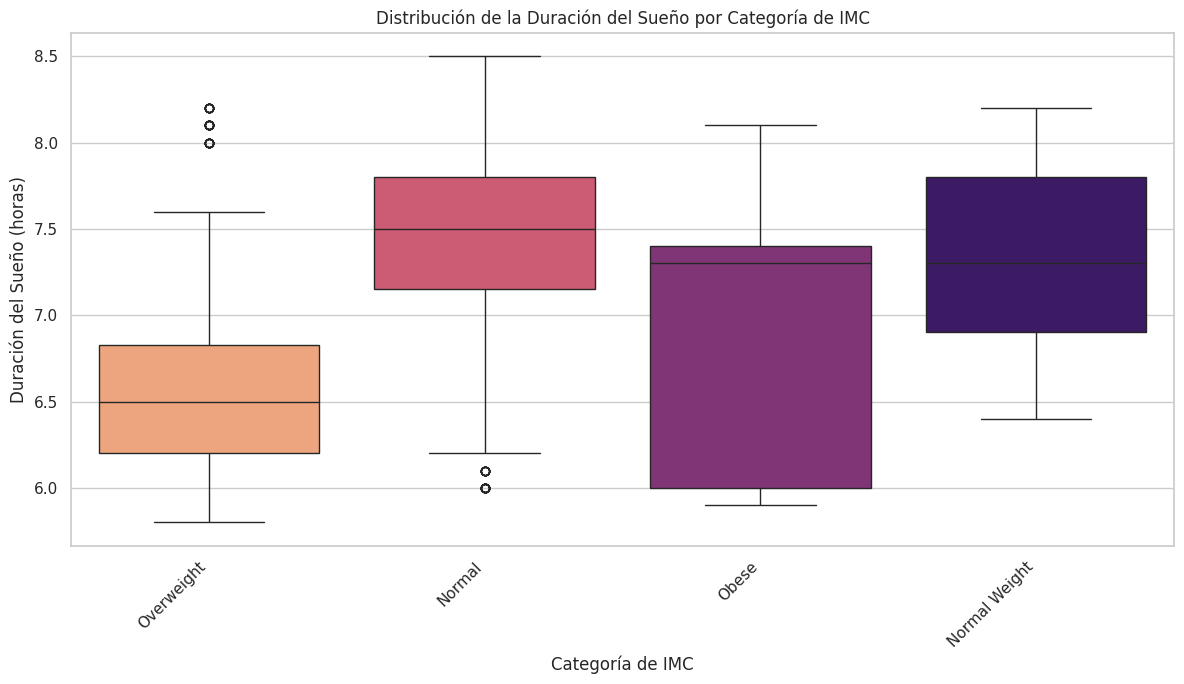

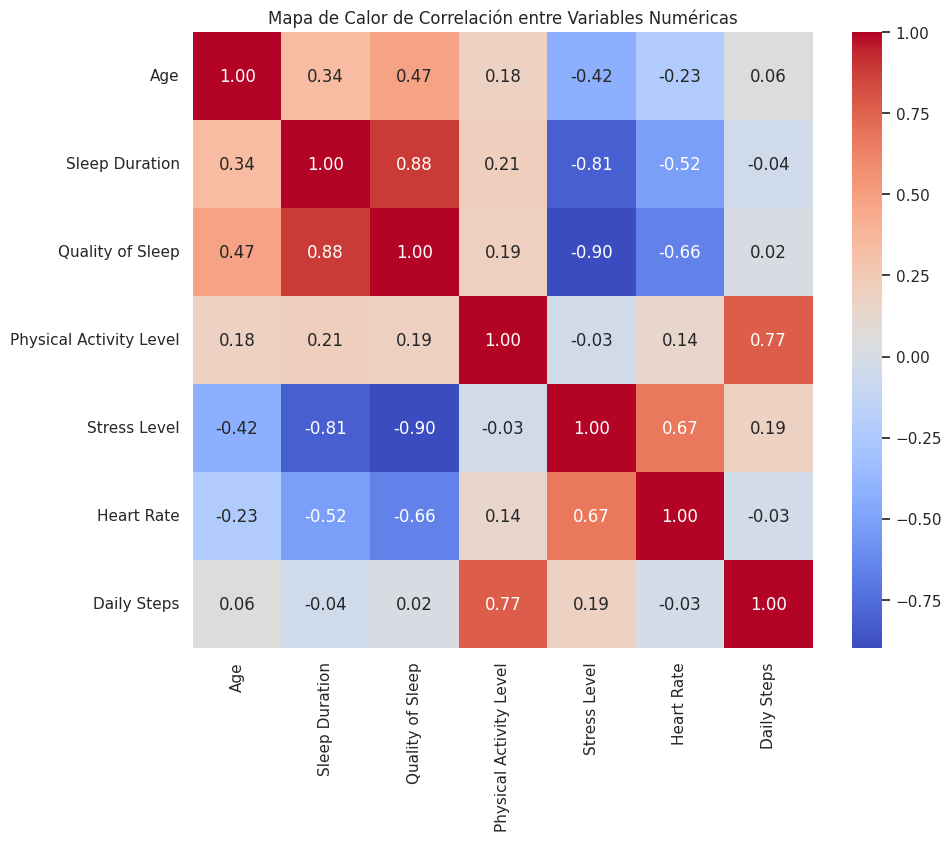

<ipython-input-173-e5d8e639c52b>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Sleep Disorder', y='Age', data=df, palette=vibrant_palette)


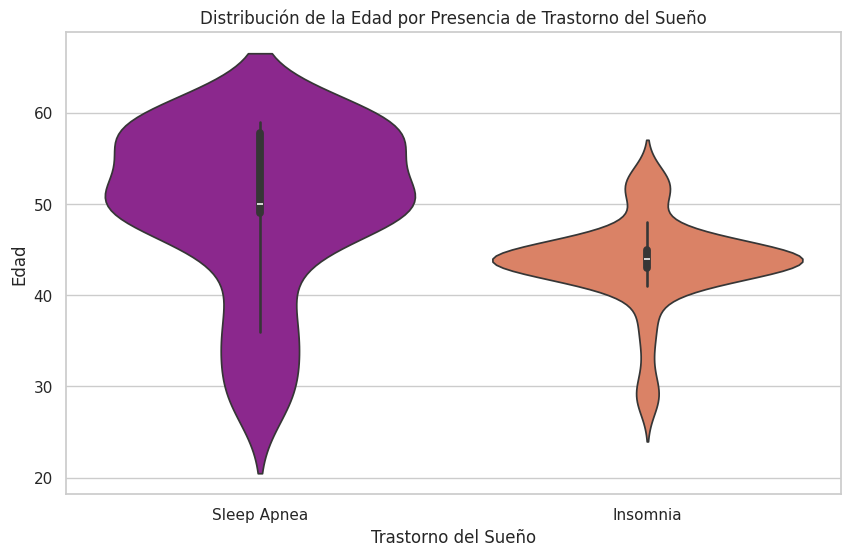

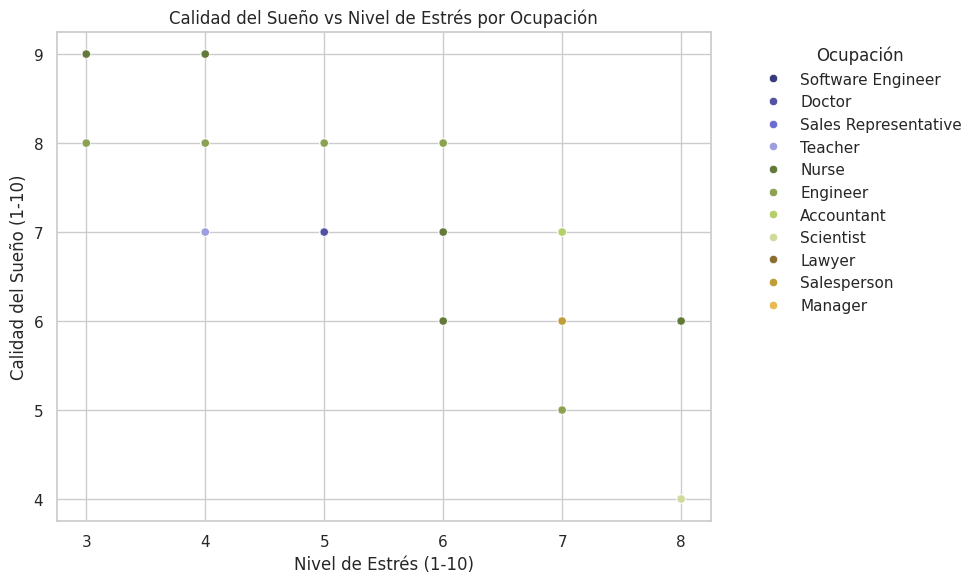

<ipython-input-173-e5d8e639c52b>:61: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Daily Steps', y='Quality of Sleep', data=df, palette=[vibrant_palette])


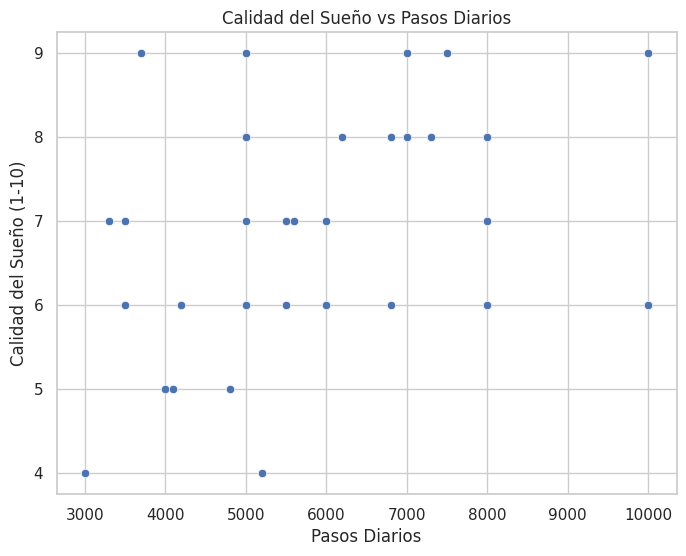

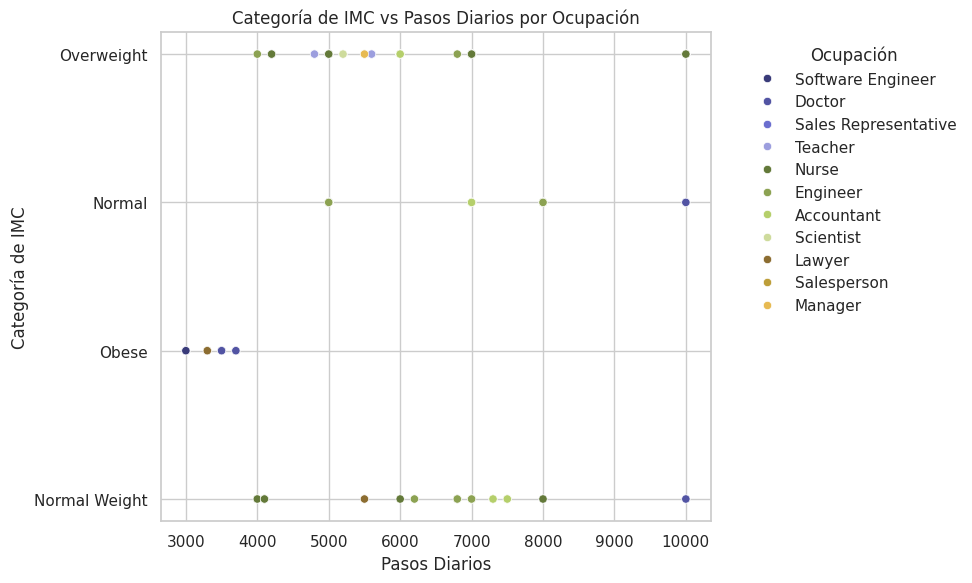

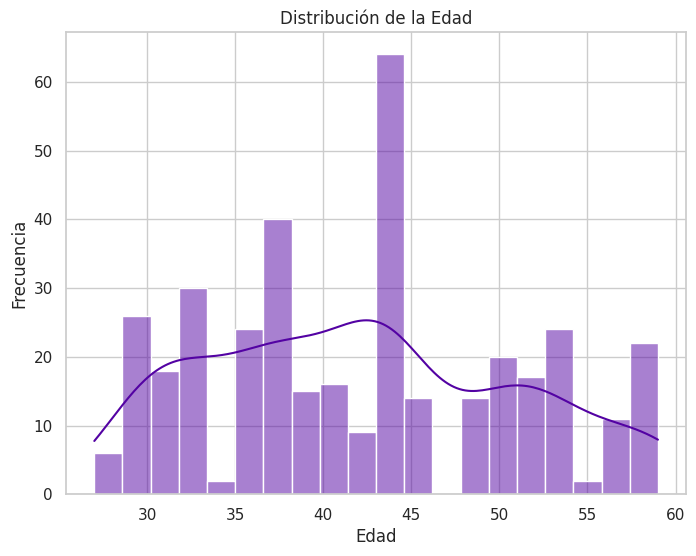

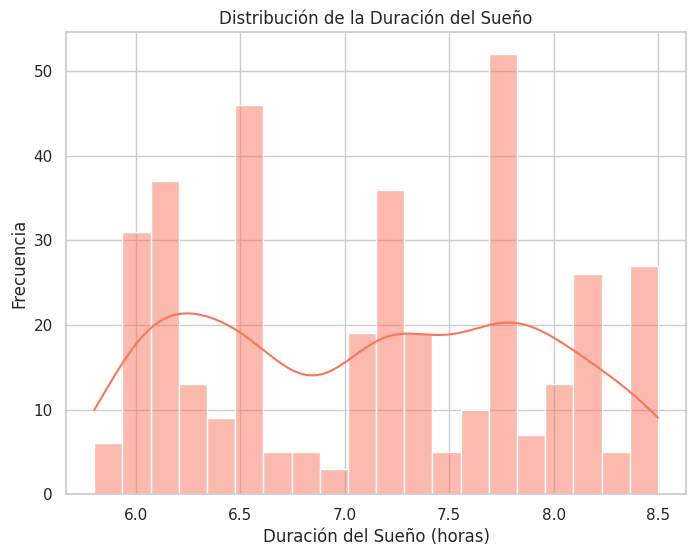

<ipython-input-173-e5d8e639c52b>:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Occupation', data=df, order=df['Occupation'].value_counts().index, palette=categorical_vibrant)


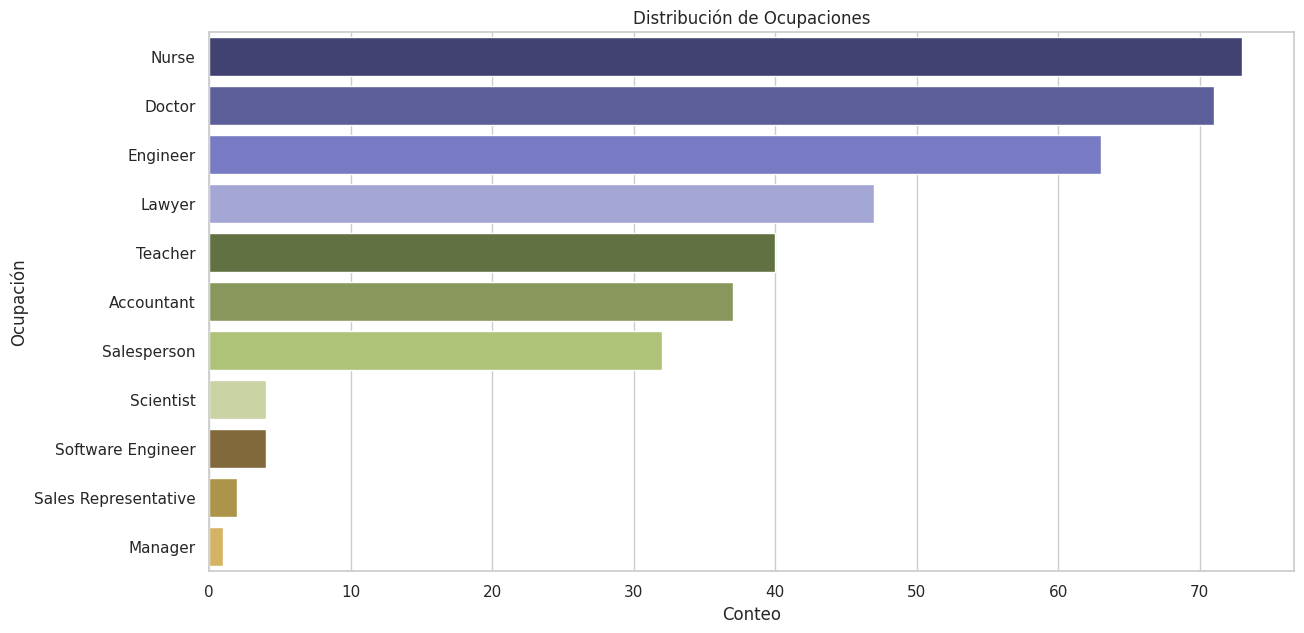

<ipython-input-173-e5d8e639c52b>:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quality of Sleep', y='Occupation', data=df, errorbar='sd', palette=vibrant_palette, order=df.groupby('Occupation')['Quality of Sleep'].mean().sort_values(ascending=False).index)


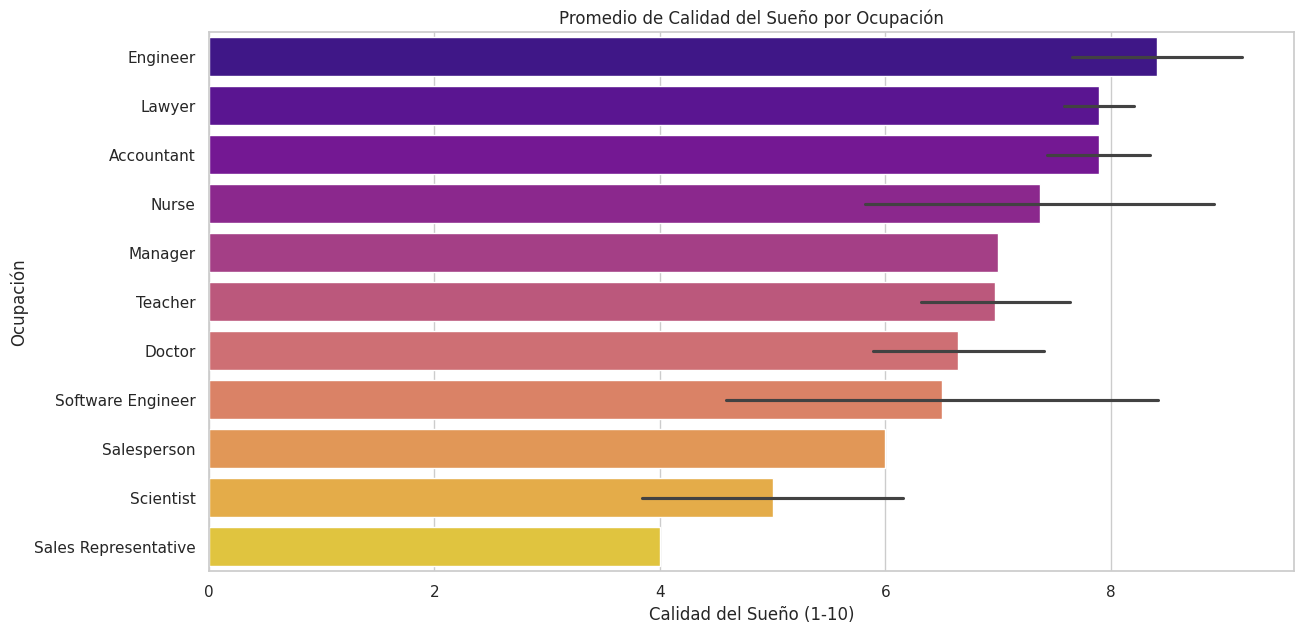

<ipython-input-173-e5d8e639c52b>:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stress Level', y='Occupation', data=df, errorbar='sd', palette=orange_purple_palette, order=df.groupby('Occupation')['Stress Level'].mean().sort_values(ascending=False).index)


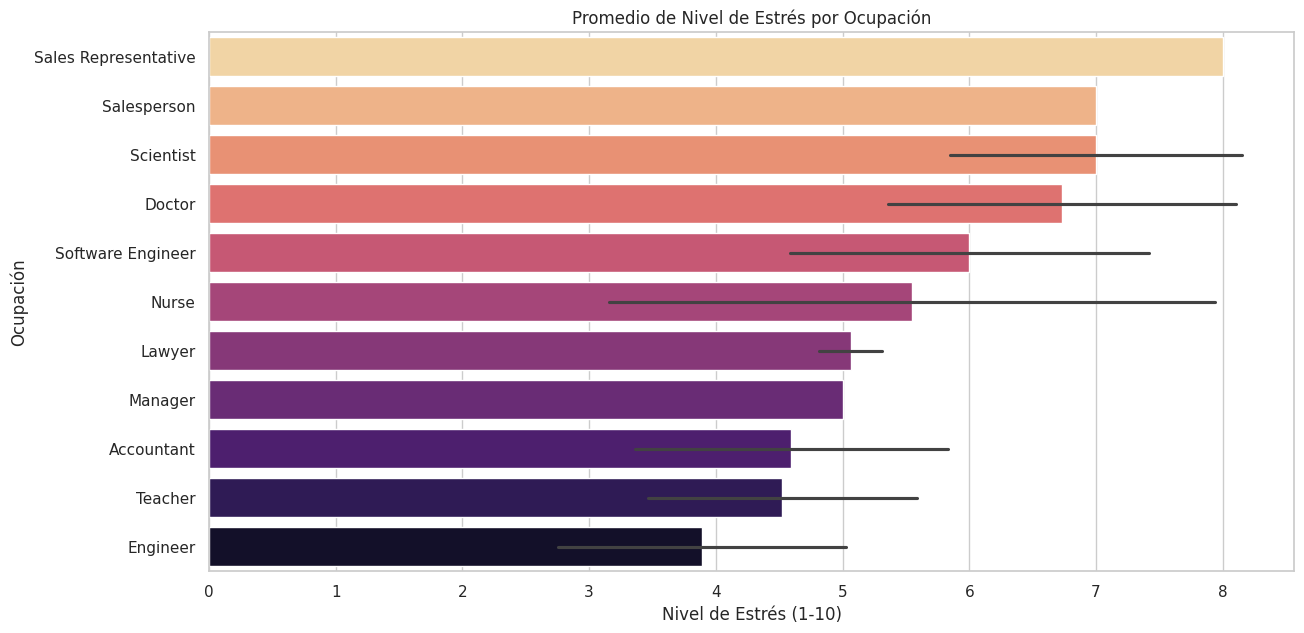

<Figure size 1500x800 with 0 Axes>

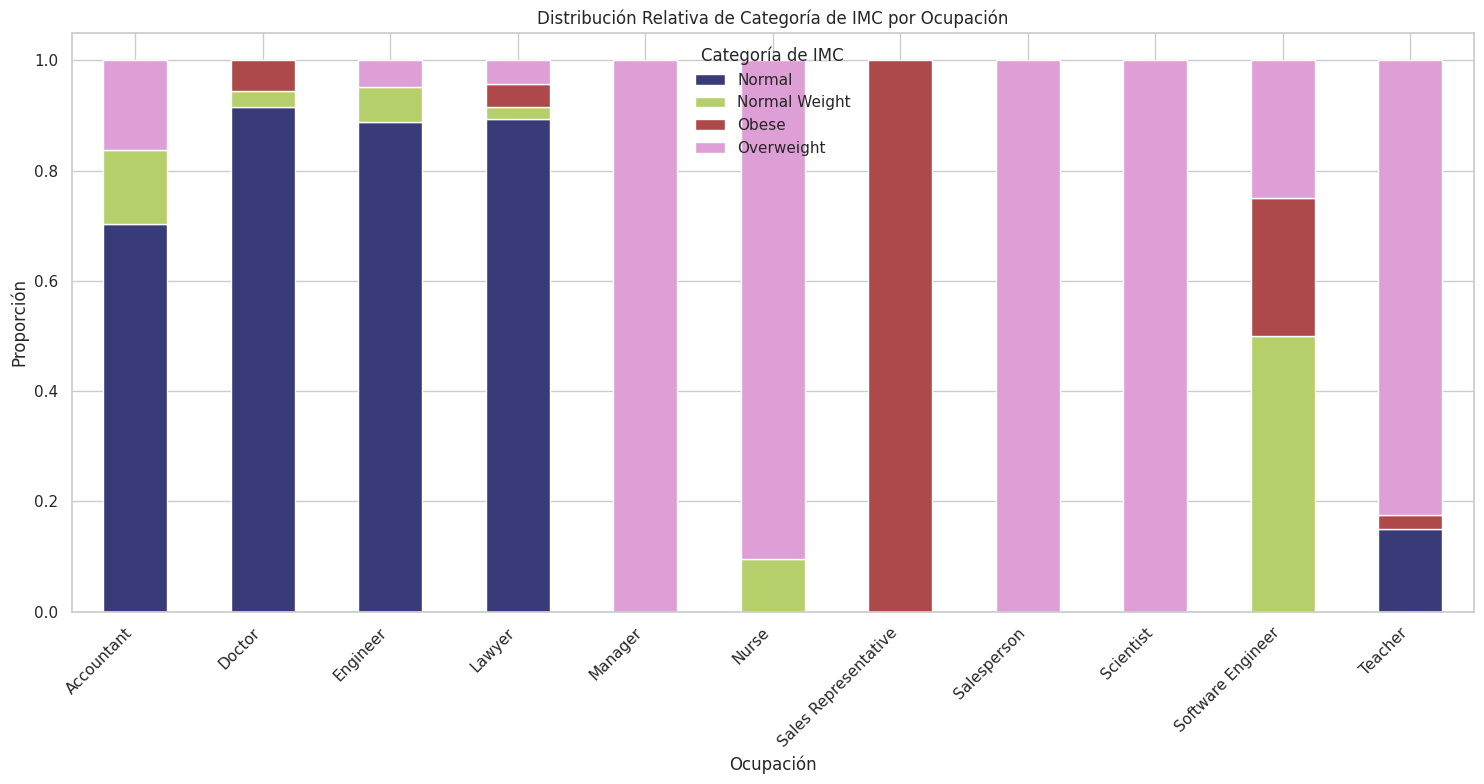

<ipython-input-173-e5d8e639c52b>:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sleep Disorder', data=df, palette=vibrant_palette)


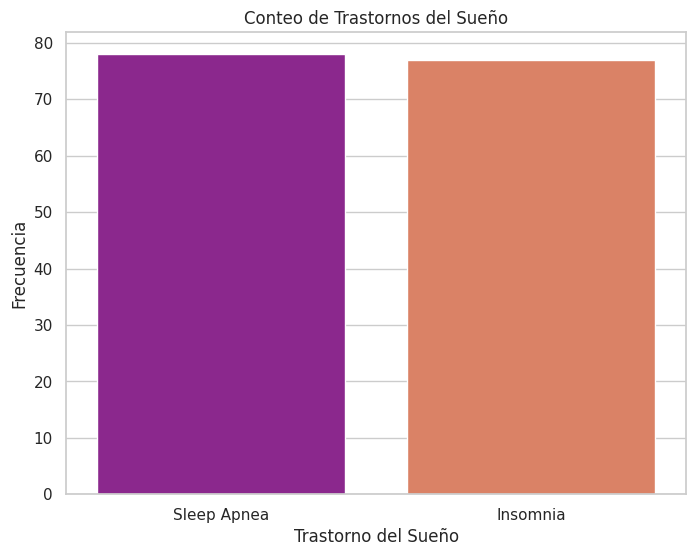

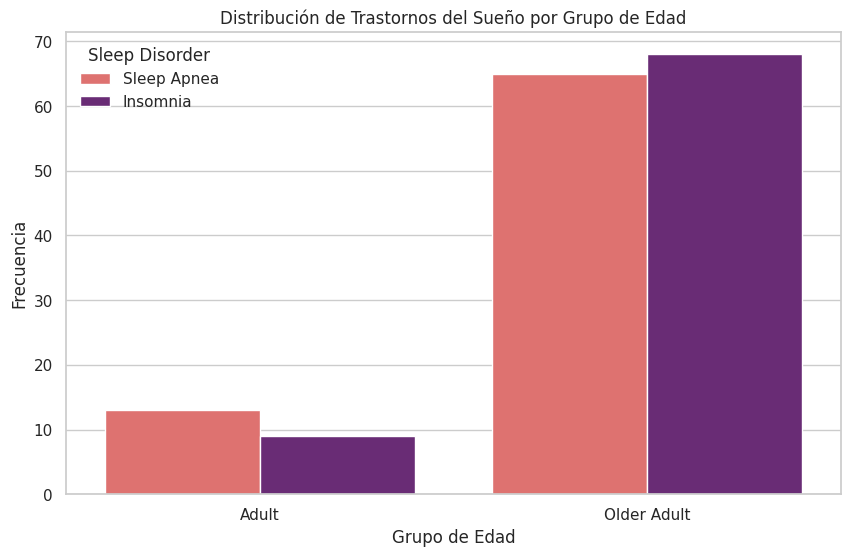

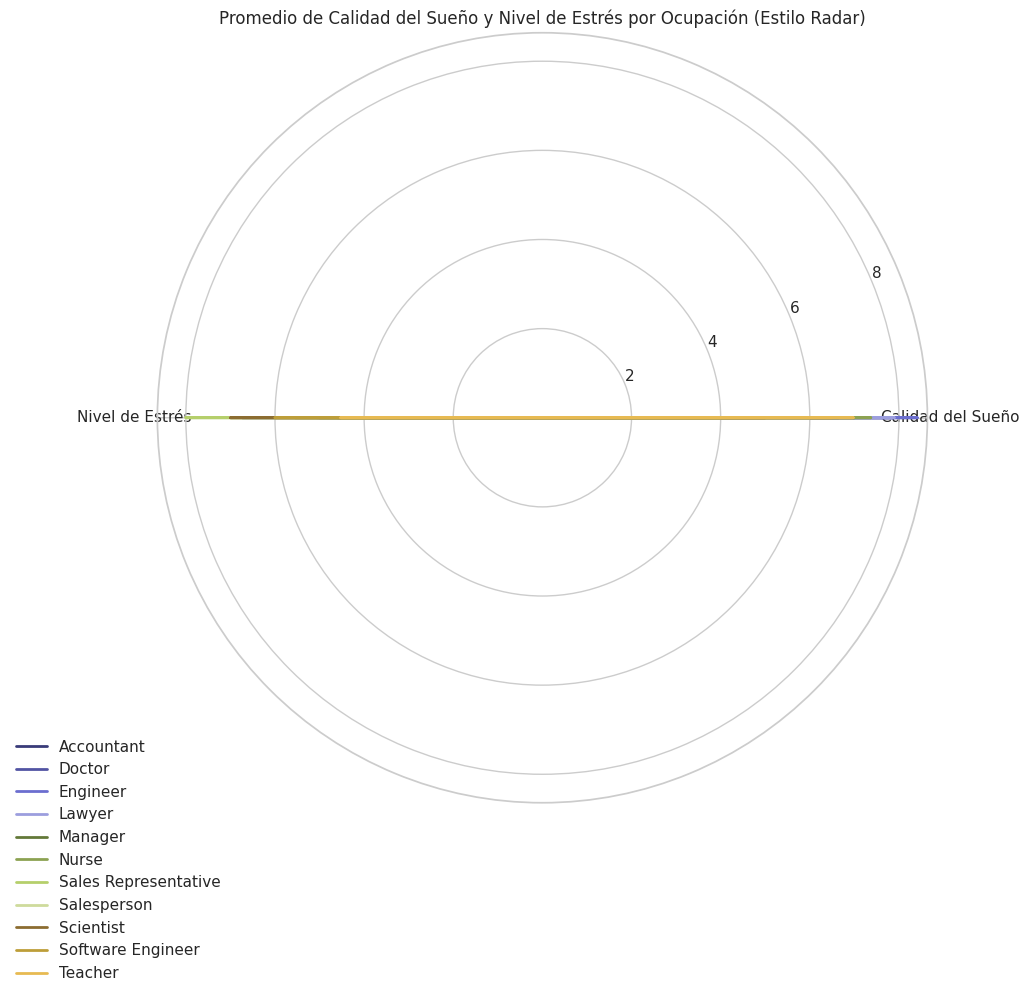

In [173]:
# Instala seaborn si no lo tienes
try:
    import seaborn as sns
except ImportError:
    !pip install seaborn
    import seaborn as sns

import matplotlib.pyplot as plt

# Configura el estilo de los gráficos
sns.set(style="whitegrid")
vibrant_palette = "plasma" # Una paleta que tiene tonos morados y rosas
orange_purple_palette = "magma_r" # 'magma' invertido tiene naranjas y morados
categorical_vibrant = "tab20b" # Una paleta categórica con tonos variados

# Gráfico de barras: Promedio de calidad del sueño por género
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Quality of Sleep', data=df, errorbar='sd', palette=vibrant_palette)
plt.title('Promedio de Calidad del Sueño por Género')
plt.xlabel('Género')
plt.ylabel('Calidad del Sueño (1-10)')
plt.show()

# Gráfico de caja: Distribución de la duración del sueño por categoría de BMI
plt.figure(figsize=(12, 7))
sns.boxplot(x='BMI Category', y='Sleep Duration', data=df, palette=orange_purple_palette)
plt.title('Distribución de la Duración del Sueño por Categoría de IMC')
plt.xlabel('Categoría de IMC')
plt.ylabel('Duración del Sueño (horas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mapa de calor: Correlación entre variables numéricas (manteniendo esquema de correlación)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación entre Variables Numéricas')
plt.show()

# Gráfico de violín: Distribución de la edad por presencia de trastorno del sueño
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sleep Disorder', y='Age', data=df, palette=vibrant_palette)
plt.title('Distribución de la Edad por Presencia de Trastorno del Sueño')
plt.xlabel('Trastorno del Sueño')
plt.ylabel('Edad')
plt.show()

# Gráfico de dispersión: Calidad del sueño vs Nivel de estrés por ocupación
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Stress Level', y='Quality of Sleep', hue='Occupation', data=df, palette=categorical_vibrant)
plt.title('Calidad del Sueño vs Nivel de Estrés por Ocupación')
plt.xlabel('Nivel de Estrés (1-10)')
plt.ylabel('Calidad del Sueño (1-10)')
plt.legend(title='Ocupación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Gráfico de dispersión: Calidad del sueño vs Pasos diarios
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Daily Steps', y='Quality of Sleep', data=df, palette=[vibrant_palette])
plt.title('Calidad del Sueño vs Pasos Diarios')
plt.xlabel('Pasos Diarios')
plt.ylabel('Calidad del Sueño (1-10)')
plt.show()

# Gráfico de dispersión: BMI vs Pasos diarios por ocupación
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Daily Steps', y='BMI Category', hue='Occupation', data=df, palette=categorical_vibrant)
plt.title('Categoría de IMC vs Pasos Diarios por Ocupación')
plt.xlabel('Pasos Diarios')
plt.ylabel('Categoría de IMC')
plt.legend(title='Ocupación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Histograma: Distribución de la edad
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True, bins=20, color=sns.color_palette(vibrant_palette)[0])
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

# Histograma: Distribución de la duración del sueño
plt.figure(figsize=(8, 6))
sns.histplot(df['Sleep Duration'], kde=True, bins=20, color=sns.color_palette(orange_purple_palette)[1])
plt.title('Distribución de la Duración del Sueño')
plt.xlabel('Duración del Sueño (horas)')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico de barras: Conteo de ocupaciones
plt.figure(figsize=(14, 7))
sns.countplot(y='Occupation', data=df, order=df['Occupation'].value_counts().index, palette=categorical_vibrant)
plt.title('Distribución de Ocupaciones')
plt.xlabel('Conteo')
plt.ylabel('Ocupación')
plt.show()

# Gráfico de barras: Promedio de calidad del sueño por ocupación
plt.figure(figsize=(14, 7))
sns.barplot(x='Quality of Sleep', y='Occupation', data=df, errorbar='sd', palette=vibrant_palette, order=df.groupby('Occupation')['Quality of Sleep'].mean().sort_values(ascending=False).index)
plt.title('Promedio de Calidad del Sueño por Ocupación')
plt.xlabel('Calidad del Sueño (1-10)')
plt.ylabel('Ocupación')
plt.show()

# Gráfico de barras: Promedio de nivel de estrés por ocupación
plt.figure(figsize=(14, 7))
sns.barplot(x='Stress Level', y='Occupation', data=df, errorbar='sd', palette=orange_purple_palette, order=df.groupby('Occupation')['Stress Level'].mean().sort_values(ascending=False).index)
plt.title('Promedio de Nivel de Estrés por Ocupación')
plt.xlabel('Nivel de Estrés (1-10)')
plt.ylabel('Ocupación')
plt.show()

# Gráfico de barras apiladas: Distribución de la categoría de IMC por ocupación
plt.figure(figsize=(15, 8))
occ_bmi_counts = df.groupby('Occupation')['BMI Category'].value_counts(normalize=True).unstack().fillna(0)
occ_bmi_counts.plot(kind='bar', stacked=True, colormap=categorical_vibrant, figsize=(15, 8))
plt.title('Distribución Relativa de Categoría de IMC por Ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría de IMC')
plt.tight_layout()
plt.show()

# Gráfico de barras: Conteo de trastornos del sueño
plt.figure(figsize=(8, 6))
sns.countplot(x='Sleep Disorder', data=df, palette=vibrant_palette)
plt.title('Conteo de Trastornos del Sueño')
plt.xlabel('Trastorno del Sueño')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico de barras: Distribución de trastornos del sueño por grupo de edad
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_group', hue='Sleep Disorder', data=df, palette=orange_purple_palette)
plt.title('Distribución de Trastornos del Sueño por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico de polígonos (radar) - adaptado con paleta de colores
occupation_avg = df.groupby('Occupation')[['Quality of Sleep', 'Stress Level']].mean().reset_index()

categories = ['Calidad del Sueño', 'Nivel de Estrés']
n_categories = len(categories)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i in range(len(occupation_avg)):
    values = occupation_avg.iloc[i][['Quality of Sleep', 'Stress Level']].tolist()
    angles = [n / float(n_categories) * 2 * 3.14159 for n in range(n_categories)]
    angles += angles[:1]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=occupation_avg['Occupation'].iloc[i], color=sns.color_palette(categorical_vibrant)[i % len(sns.color_palette(categorical_vibrant))])
    ax.fill(angles[:-1], values[:-1], alpha=0.25, color=sns.color_palette(categorical_vibrant)[i % len(sns.color_palette(categorical_vibrant))])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticks([2, 4, 6, 8]) # Ajusta los ticks según la escala de tus datos
ax.set_yticklabels(['2', '4', '6', '8'])
ax.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Promedio de Calidad del Sueño y Nivel de Estrés por Ocupación (Estilo Radar)')
plt.show()

# Reporte

# Introducción

En este proyecto tomamos el conjunto de datos [Sleep Health and Lifestyle Dataset | Kaggle](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset) en donde se encuentran los datos de distintas personas como su profesión, su actividad física y la calidad de sueño. Tomaremos este conjunto de datos para conocer que cosas son las que afectan al sueño como por ejemplo la cantidad de actividad física, la profesión y la presión a la que cada uno de ellos se somete.

Las preguntas que buscaremos responder con los datos de este conjunto son las siguientes:

- ¿Quiénes tienen peor calidad del sueño, hombres o mujeres?

- ¿Existe una relación entre la calidad del sueño de las personas y su profesión?

- ¿La actividad física afecta al sueño?

- ¿Qué profesión presenta la peor calidad de sueño?

- ¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?

- ¿En qué rango de edades se encuentran la mayor cantidad de trastornos del sueño?

- La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?

Estas preguntas nos servirán como punto de partida en nuestro análisis buscando extraer la mayor cantidad de información que se pueda del conjunto, es importante señalar que para el análisis de este conjunto de datos solamente haremos uso de la librería **Pandas** por lo que en este análisis no encontraremos gráficos.

## Análisis del conjunto

### Análisis General

Sabemos que en el conjunto de datos contamos con *374* filas y *13* columnas de datos, de las cuales sabemos que en general los datos se dividen de la siguiente forma:

|Género|Cantidad|
|---|---|
|Hombres|189|
|Mujeres|185|

Esto nos da un vistazo general del conjunto y podemos decir que el conjunto se encuentran en proporción, respecto a la cantidad de hombre y mujeres.

## Clasificación dada por edad

En el conjunto podemos encontrar las edades de las personas, con respecto a las edades podemos encontrar lo siguiente:

- La edad más baja es de *27* años

- La edad más alta es de *59* años

Lo que podemos decir que el conjunto de datos toma en cuenta a personas que ya se encuentran en la edad laboral iniciando en el trabajo o con pocos años en el mismo, o de personas cercanas a jubilarse.

La edad promedio del conjunto de datos es de *42* años y la desviación estándar es de *8.67*, lo que quiere decir que en este conjunto podemos encontrar datos muy dispersos lo que puede deberse a los pocos datos recabados.  

Para apoyarnos en este análisis se agregó una nueva columna al conjunto de datos a la que se le llamó `Age_group` en la cuál se clasifico la edad de las personas de la siguiente manera:  

- Edad menor o igual a 40: `Adulto`

- Edad mayor a 40: `Adulto viejo`  

Tomando en cuenta este ordenamiento de los datos tenemos lo siguiente:

|Clasificación|Cantidad|
|---|---|
|Adulo Viejo|209|
|Adulto|165|


Finalmente el promedio de edades por cada género queda de la siguiente forma:  

|Gender|mean|std|
|---|---|---|
|Female|47\.40|8\.10|
|Male|37\.07|5\.66|

Podemos ver que existe una diferencia de `10` años en el promedio de edades de ambos géneros, y también notamos un diferencia grande en la desviación estándar, siendo ésta de `3` años.


## Ocupaciones

|Ocupación |Género|Cantidad|
|---|---|---|
|Accountant|Female|36|
||Male|1|
|Doctor|Male|69|
||Female|2|
|Engineer|Female|32|
||Male|31|
|Lawyer|Male|45|
|| Female|2|
|Manager|Female|1|
|Nurse|Female|73|
|Sales Representative|Male|2|
|Salesperson|Male|32|
|Scientist|Female|4|
|Software Engineer|Male|4|
|Teacher|Female|35|
||Male|5|

En esta gráfica notamos la siguiente:
- Las ocupaciones en donde hay más presencia de mujeres son:
	- Contador
	- Ingeniería
	- Gerente
	- Enfermería
	- Ciencia
	- Maestro
- Las ocupaciones en donde los hombres tienen más presencia:
	- Doctor
	- Representante de ventas
	- Ventas
	- Abogado
	- Ingeniero de Software

Es importante mencionar que solamente en *Ingeniería* la diferencia es de solamente una persona.

### Calidad del Sueño

El promedio de la duración del sueño entre hombres y mujeres es la siguiente:

|Genero|Promedio del sueño|Calidad del sueño|
|---|---|---|
|Female|7.23|7.66|
|Male|7.04|6.97|

Podemos ver que en general, las mujeres tienen un mejor sueño que los hombres no solamente en cantidad sino que en calidad, para profundizar más, obtendremos los mismos datos pero ahora en cada una de las profesiones del conjunto.

|Occupation|Quality of Sleep|Sleep Duration|
|---|---|---|
|Sales Representative|4\.0|5\.9|
|Scientist|5\.0|6\.0|
|Salesperson|6\.0|6\.40|
|Software Engineer|6\.5|6\.75|
|Doctor|6\.65|6\.97|
|Teacher|6\.975|6\.69|
|Manager|7\.0|6\.9|
|Nurse|7\.37|7\.06|
|Accountant|7\.89|7\.11|
|Lawyer|7\.89|7\.41|
|Engineer|8\.41|7\.99|


En estas tablas podemos ver que las peores ocupaciones que tienen la peor calidad y cantidad de sueño son:
- Representante de Ventas
- Científico
- Ventas

Y aquellas que tienen mejor calidad y tiempo de sueño son:
- Ingeniero
- Abogado
- Contador

En las profesiones donde peor calidad y cantidad de sueño hay se encuentran más hombres que mujeres.

### Problemas de salud

Finalmente buscaremos que tan buena salud tienen cada una de las personas en las distintas profesiones, con este dato podremos sacar nuestras conclusiones y podremos responder las preguntas que nos hicimos en un inicio al comenzar con nuestro análisis.

| Occupation           | BMI Category    | Count |
|----------------------|-----------------|-------|
| Lawyer               | Normal Weight   | 1     |
| Software Engineer    | Overweight      | 1     |
|                      | Obese           | 1     |
| Manager              | Overweight      | 1     |
| Teacher              | Obese           | 1     |
| Doctor               | Normal Weight   | 2     |
| Lawyer               | Obese           | 2     |
|                      | Overweight      | 2     |
| Software Engineer    | Normal Weight   | 2     |
| Sales Representative | Obese           | 2     |
| Engineer             | Overweight      | 3     |
|                      | Normal Weight   | 4     |
| Doctor               | Obese           | 4     |
| Scientist            | Overweight      | 4     |
| Accountant           | Normal Weight   | 5     |
|                      | Overweight      | 6     |
| Teacher              | Normal          | 6     |
| Nurse                | Normal Weight   | 7     |
| Accountant           | Normal          | 26    |
| Salesperson          | Overweight      | 32    |
| Teacher              | Overweight      | 33    |
| Lawyer               | Normal          | 42    |
| Engineer             | Normal          | 56    |
| Doctor               | Normal          | 65    |
| Nurse                | Overweight      | 66    |

Otro punto importante a tener en cuenta es saber si la cantidad de pasos al día afecta a la salud y a la calidad del sueño, para conocer esto tendremos el promedio de los pasos diarios, el nivel de actividad física, duración del sueño y la calidad del sueño en cada una de las profesiones.

|Occupation|Daily Steps|Physical Activity Level|Sleep Duration|Quality of Sleep|
|---|---|---|---|---|
|Sales Representative|3000\.0|30\.0|5\.9|4\.0|
|Scientist|5350\.0|41\.0|6\.0|5\.0|
|Manager|5500\.0|55\.0|6\.9|7\.0|
|Software Engineer|5800\.0|48\.0|6\.75|6\.5|
|Teacher|5957\.5|45\.62|6\.69|6\.97|
|Engineer|5980\.95|51\.86|7\.99|8\.41|
|Salesperson|6000\.0|45\.0|6\.40|6\.0|
|Doctor|6808\.45|55\.35|6\.97|6\.65|
|Accountant|6881\.08|58\.11|7\.11|7\.89|
|Lawyer|7661\.70|70\.42|7\.41|7\.89|
|Nurse|8057\.53|78\.59|7\.06|7\.37|

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

# Conclusiones

Este conjunto de datos nos sirve para darnos un vistazo general de cada una de las profesiones y como éstas afecta a la salud de las personas. Digo general porque un problema de este conjunto es la cantidad de datos que tiene, ya que al contar solamente con *307* filas son muy pocas para todo el margen de edad que se tomó. Eso lo podemos notar al obtener el promedio de las edades y la desviación estándar por lo que, al terminar con nuestro análisis, podemos decir que hacen falta más datos o en su caso reducir el margen de edades de los encuestados.

Pasando al sueño de cada una de las personas tenemos lo siguiente:

Las mujeres en términos generales tienen una mejor calidad y cantidad de sueño respecto a los hombres ya que, las mujeres pueden tener un mejor control de estrés o porque las mujeres a las que se les hizo la encuesta parecen tener profesiones en las que se habla con menos personas que las profesiones de los hombres.

Esto lo podemos acompañar si tomamos solamente las primeras cinco profesiones que presentan la mejor calidad y cantidad de sueño:

- Ingeniería
- Abogado
- Contador
- Enfermería
- Gerente

De estas profesiones en tres se encuentran más mujeres (Contador, Enfermería y Gerente) en una hay más hombres (Abogado) y en Ingeniería se encuentra la diferencia de una persona entre ambos.

Muchas de estas profesiones también se repiten cuando revisamos la cantidad de pasos al día, podemos ver que las cinco profesiones donde más pasos al día se dan son:

- Enfermería
- Abogado
- Contador
- Doctor
- Vendedor

En la mayoría de estas personas podemos ver que caminar forma una parte fundamental de ellas por lo que no es de extrañar que éstas presenten un promedio alto de pasos al día y esto también se ve en la salud del sueño, ya que si vemos la tabla de los pasos al día podemos ver que en ella existe una relación que entre más pasos se den mejor va a ser el sueño.

Aunque esta misma relación no se nota cuando hablamos del índice de masa corporal, porque de la lista anterior podemos ver que en las siguientes se encuentran muchas personas con sobrepeso:

- Enfermería
- Vendedor

Finalmente, las preguntas hechas alrededor de la edad de los encuestados no se respondieron ya que se encontró que el rango de edades es muy alto y se cuenta con muy pocos datos por lo que las respuestas que se puedan encontrar en este ámbito no pueden llegar a ser relevantes con la realidad.